В текущем проекте я взяла датасет с платформы Kaggle с данными о клиентах мобильного оператора. В нем представлена информация: о личных данных клиента (есть партнер, иждивенцы, (не)пожилой), о технической возможности подключения к услугам, о подключенных услугах, срок подключения, типа договора/оплаты и отказался или нет клиент от продолжения договора.

Для начала нам нужно прочитать и посмотреть на данные, затем привести их к удобному для анализа виду. 

Далее приступим к поиску закономерностей и причин оттока, выявим наиболее стабильные категории клиентов и приносящие больше всего денег (сегментация пользователей, АBC-анализ).



## Чтение и преобразование файла

In [94]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.reset_defaults()
plt.style.use('default')
# from scipy import stats
# from scipy.stats import binom, norm

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
np.random.seed(42)
%matplotlib inline

In [95]:
df = pd.read_csv('../datasets/customer_churn.csv', delimiter=',', encoding='utf-8')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [96]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [97]:
df['SeniorCitizen'] = df['SeniorCitizen'].map({0:'No', 1: 'Yes'}).astype('category')

In [98]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [99]:
# смотрим, какие можно привести к числовому формату или категории

for col in df.columns[1:]:
    if len(df[col].unique()) == 2:
        print(f'{col}:',* df[col].unique())


gender: Female Male
SeniorCitizen: No Yes
Partner: Yes No
Dependents: No Yes
PhoneService: No Yes
PaperlessBilling: Yes No
Churn: No Yes


In [100]:
# приводим к категориальному формату, предварительно убираем пробелы, чтобы все категории были одинаковые

for col in ['gender','Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'MultipleLines', 'InternetService', 'Contract', 'PaymentMethod']:
    df[col] = df[col].apply(lambda x: x.strip()).astype('category')

df['TotalCharges'] = df['TotalCharges'].apply(lambda x: x.strip()).apply(lambda x: float(x) if x else 0.0)
df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1}).astype('int64')

# ABC-анализ и сегментация пользователей в разрезе LTV (TotalCharges).

## Подготовим данные

In [101]:
# Выделим столбцы с id клиента и суммой, потраченной каждым клиентом
df_abc = df[['customerID', 'TotalCharges']].copy()
df_abc.head()

,customerID,TotalCharges
0,7590-VHVEG,29.85
1,5575-GNVDE,1889.50
2,3668-QPYBK,108.15
3,7795-CFOCW,1840.75
4,9237-HQITU,151.65


In [102]:
# сортируем total charges по убыванию
df_abc = df_abc.sort_values('TotalCharges', ascending=False).reset_index(drop=True)
# посчитаем общую выручку компании, долю каждого клиента от общей выручки
total_revenue = df_abc['TotalCharges'].sum()
df_abc['revenue_share'] = df_abc['TotalCharges'] / total_revenue * 100
#  считаем накопленную долю каждого клиента
df_abc['cumulative_share'] = df_abc['revenue_share'].cumsum()

df_abc.head()

,customerID,TotalCharges,revenue_share,cumulative_share
0,2889-FPWRM,8684.80,0.054090,0.054090
1,7569-NMZYQ,8672.45,0.054013,0.108103
2,9739-JLPQJ,8670.10,0.053999,0.162102
3,9788-HNGUT,8594.40,0.053527,0.215629
4,8879-XUAHX,8564.75,0.053342,0.268971


In [103]:
# теперь нужно присвоить категорию АВС: А = 0-80%, В = 80-95%, С = 95-100%
def assign_abc_mark(cumulative_sum, suffix='_total'):
    return f'A{suffix}' if cumulative_sum <= 80 else (f'B{suffix}' if cumulative_sum <= 95 else f'C{suffix}')

df_abc['abc_mark'] = df_abc['cumulative_share'].apply(assign_abc_mark)

# Проверим распределение
print(df_abc['abc_mark'].value_counts())

abc_mark
A_total    2701
C_total    2649
B_total    1693
Name: count, dtype: int64


## Визуализируем кривую Паретто

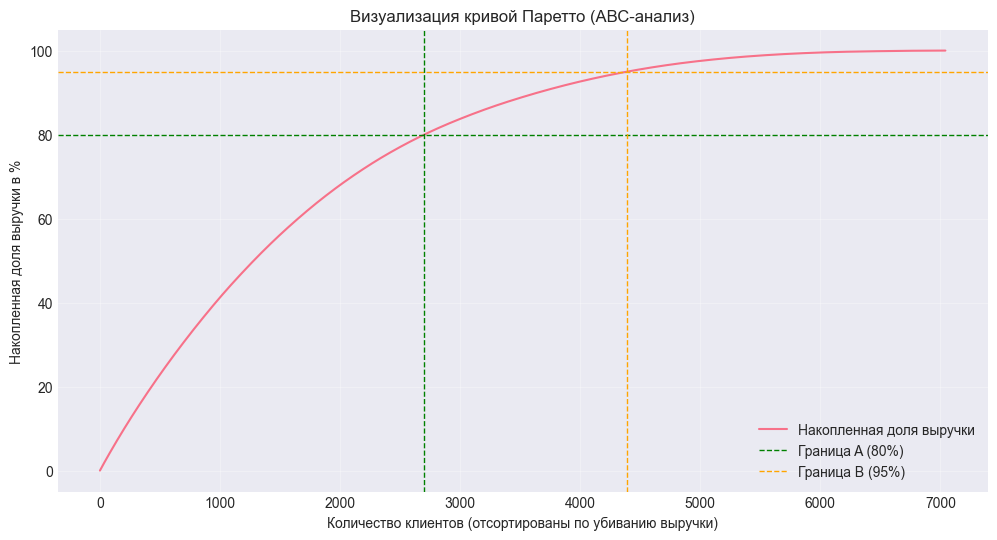

In [104]:
plt.figure(figsize=(12,6))
plt.plot(df_abc.index, df_abc['cumulative_share'], label='Накопленная доля выручки')
# Добавляем горизонтальные и вертикальные линии для границ A, B, C
plt.axhline(y=80, color='green', linestyle='--', linewidth=1, label='Граница A (80%)')
plt.axhline(y=95, color='orange', linestyle='--', linewidth=1, label='Граница B (95%)')

# Находим примерные границы по оси X (количество клиентов)
limit_a = df_abc[df_abc['cumulative_share'] <= 80].index.max()
limit_b = df_abc[df_abc['cumulative_share'] <= 95].index.max()

plt.axvline(x=limit_a, color='green', linestyle='--', linewidth=1)
plt.axvline(x=limit_b, color='orange', linestyle='--', linewidth=1)

plt.xlabel('Количество клиентов (отсортированы по убиванию выручки)')
plt.ylabel('Накопленная доля выручки в %')
plt.title('Визуализация кривой Паретто (АВС-анализ)')

plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [105]:
# теперь посмотрим на цифры, сколько клиентов составляют каждую группу и какой процент выручки
group_stats = df_abc.groupby('abc_mark').agg(
    total_revenue = ('TotalCharges', 'sum'),
    customer_count = ('customerID', 'count')
).reset_index()
# теперь посчитаем доли на соответствие закону Паретто
group_stats['revenue_share_%'] = round(group_stats['total_revenue'] / group_stats['total_revenue'].sum()*100, 2)
group_stats['customer_share_%'] = round(group_stats['customer_count'] / group_stats['customer_count'].sum() * 100,2)

group_stats


,abc_mark,total_revenue,customer_count,revenue_share_%,customer_share_%
0,A_total,12843549.90,2701,79.99,38.35
1,B_total,2409543.15,1693,15.01,24.04
2,C_total,803075.65,2649,5.00,37.61


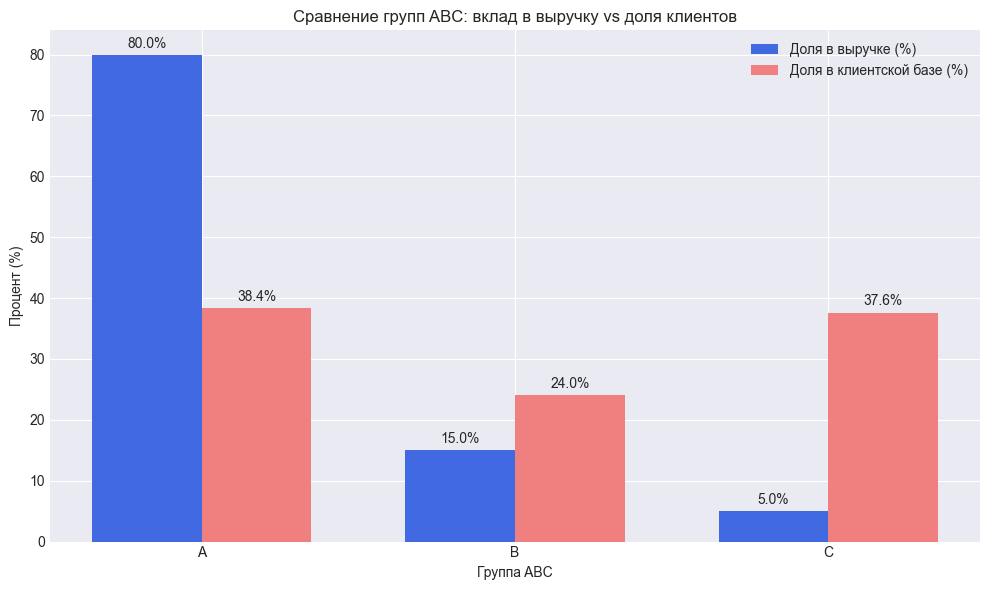

In [106]:
# Строим двойную столбчатую диаграмму
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(group_stats['abc_mark']))
width = 0.35

# Столбцы для доли выручки и доли клиентов
bars1 = ax.bar(x - width/2, group_stats['revenue_share_%'], width, label='Доля в выручке (%)', color='royalblue')
bars2 = ax.bar(x + width/2, group_stats['customer_share_%'], width, label='Доля в клиентской базе (%)', color='lightcoral')

# Добавляем подписи
ax.set_xlabel('Группа ABC')
ax.set_ylabel('Процент (%)')
ax.set_title('Сравнение групп ABC: вклад в выручку vs доля клиентов')
ax.set_xticks(x)
ax.set_xticklabels(['A', 'B', 'C'])
ax.legend()
ax.bar_label(bars1, padding=3, fmt='%.1f%%')
ax.bar_label(bars2, padding=3, fmt='%.1f%%')

plt.tight_layout()
plt.show()

In [107]:
df = df.merge(df_abc[['customerID', 'abc_mark']], how='left', on='customerID')

churn_by_abc = df.groupby('abc_mark')['Churn'].agg(['sum', 'mean', 'count'])
churn_by_abc['mean'] = churn_by_abc['mean'] * 100

print("Отток по группам ABC:")
print(churn_by_abc.round(2))

Отток по группам ABC:
           sum   mean  count
abc_mark                    
A_total    492  18.22   2701
B_total    374  22.09   1693
C_total   1003  37.86   2649


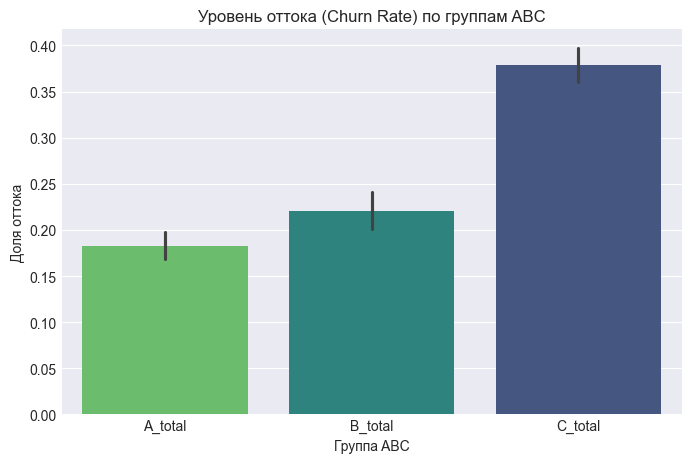

In [108]:
# Визуализируем отток
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='abc_mark', y='Churn', order=['A_total', 'B_total', 'C_total'], hue='abc_mark', palette='viridis')
plt.title('Уровень оттока (Churn Rate) по группам ABC')
plt.ylabel('Доля оттока')
plt.xlabel('Группа ABC')
plt.show()

### Интерпретация результата
Группа А, приносящая 80% прибыли компании и составляющая ~ 40% ее аудитории -- наиболее устойчива к оттоку, доля оттока менее 20%

## Сегментация по ARPU (MonthlyCharges) + tenure
Делим клиентов на группы по среднемесячному платежу и по сроку подписки.

In [109]:
df_charges = df[['customerID', 'tenure', 'MonthlyCharges', 'Churn', 'TotalCharges', 'abc_mark']].copy()
df_charges['ARPU_group'] = pd.qcut(df_charges['MonthlyCharges'], q=3, labels=['low_ARPU', 'medium_ARPU', 'high_ARPU'])
df_charges['tenure_group'] = pd.cut(
    df_charges['tenure'],
    bins=[0, 6, 12, 24, 36, 48, 60, 72],
    labels=['0-6 мес', '6-12 мес', '12-24 мес', '24-36 мес', '36-48 мес', '48-60 мес', '60+ мес']
)


pivot_table = pd.crosstab(
    [df_charges['ARPU_group'], df_charges['tenure_group']],
    df_charges['Churn'],
    normalize='index'
)*100
print("Отток в разрезе ARPU и стажа:")
print(pivot_table.round(1))

Отток в разрезе ARPU и стажа:
Churn                        0     1
ARPU_group  tenure_group            
low_ARPU    0-6 мес       63.0  37.0
            6-12 мес      83.2  16.8
            12-24 мес     89.5  10.5
            24-36 мес     94.8   5.2
            36-48 мес     94.2   5.8
            48-60 мес     95.5   4.5
            60+ мес       98.8   1.2
medium_ARPU 0-6 мес       36.8  63.2
            6-12 мес      64.8  35.2
            12-24 мес     71.5  28.5
            24-36 мес     82.4  17.6
            36-48 мес     81.9  18.1
            48-60 мес     91.5   8.5
            60+ мес       96.6   3.4
high_ARPU   0-6 мес       22.8  77.2
            6-12 мес      30.9  69.1
            12-24 мес     48.6  51.4
            24-36 мес     60.5  39.5
            36-48 мес     69.1  30.9
            48-60 мес     75.4  24.6
            60+ мес       89.5  10.5


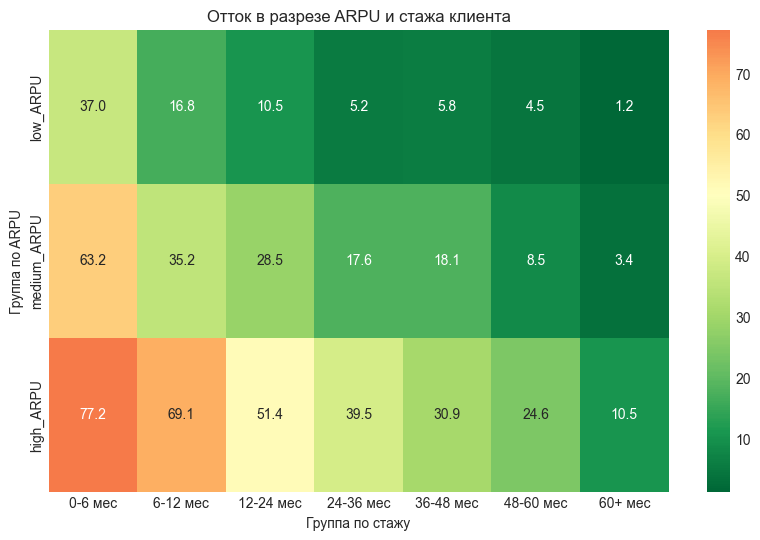

In [110]:
plt.figure(figsize=(10, 6))
pivot_unstack = pivot_table[1].unstack()  # Берем только отток
sns.heatmap(pivot_unstack, annot=True, fmt='.1f', cmap='RdYlGn_r', center=50)
plt.title('Отток в разрезе ARPU и стажа клиента')
plt.ylabel('Группа по ARPU')
plt.xlabel('Группа по стажу')
plt.show()

Наибольший отток наблюдается у клиентов, которые платят выше среднего в первый год и продолжает быть выше остальных групп на протяжении всего периода.

У группы medium самый высокий отток в первые полгода.

Нужно задуматься над удержанием тех, кто готов платить больше или среднюю цену.


# ABC (MonthlyCharges) в разрезе ARPU

In [111]:
df_charges.head()

,customerID,tenure,MonthlyCharges,Churn,TotalCharges,abc_mark,ARPU_group,tenure_group
0,7590-VHVEG,1,29.85,0,29.85,C_total,low_ARPU,0-6 мес
1,5575-GNVDE,34,56.95,0,1889.50,B_total,medium_ARPU,24-36 мес
2,3668-QPYBK,2,53.85,1,108.15,C_total,medium_ARPU,0-6 мес
3,7795-CFOCW,45,42.30,0,1840.75,B_total,low_ARPU,36-48 мес
4,9237-HQITU,2,70.70,1,151.65,C_total,medium_ARPU,0-6 мес


In [112]:
df_charges = df_charges.sort_values(by='MonthlyCharges', ascending=False)
df_charges['cumulative_sum'] = df_charges.MonthlyCharges.cumsum()
df_charges['cumulative_share'] = df_charges['cumulative_sum'] / df_charges['MonthlyCharges'].sum()*100
df_charges['abc_mark_monthly'] = df_charges['cumulative_share'].apply(lambda x :assign_abc_mark(x, '_monthly'))

df_charges.head()

,customerID,tenure,MonthlyCharges,Churn,TotalCharges,abc_mark,ARPU_group,tenure_group,cumulative_sum,cumulative_share,abc_mark_monthly
4586,7569-NMZYQ,72,118.75,0,8672.45,A_total,high_ARPU,60+ мес,118.75,0.026035,A_monthly
2115,8984-HPEMB,71,118.65,0,8477.60,A_total,high_ARPU,60+ мес,237.40,0.052048,A_monthly
4804,5734-EJKXG,61,118.60,0,7365.70,A_total,high_ARPU,60+ мес,356.00,0.078050,A_monthly
3894,5989-AXPUC,68,118.60,0,7990.05,A_total,high_ARPU,60+ мес,474.60,0.104052,A_monthly
5127,8199-ZLLSA,67,118.35,1,7804.15,A_total,high_ARPU,60+ мес,592.95,0.130000,A_monthly


In [113]:
df_charges = df_charges.drop(columns=['cumulative_sum',	'cumulative_share'])

In [114]:
df_charges.abc_mark_monthly.value_counts()

abc_mark_monthly
A_monthly    4224
B_monthly    1674
C_monthly    1145
Name: count, dtype: int64

In [115]:
cross_marks = pd.crosstab(df_charges['abc_mark'], df_charges['abc_mark_monthly']
                          )
print("Пересечение категорий (Monthly vs Total), кол-во пользователей:\n")
print(cross_marks)

Пересечение категорий (Monthly vs Total), кол-во пользователей:

abc_mark_monthly  A_monthly  B_monthly  C_monthly
abc_mark                                         
A_total                2480        221          0
B_total                 785        601        307
C_total                 959        852        838


In [116]:
charges_pivot_pct = df_charges.pivot_table(
    values='customerID',
    columns='abc_mark',
    index='abc_mark_monthly',
    aggfunc=lambda x: len(x) / len(df_charges) * 100,
    fill_value=0
).round(1)
churn_pivot = df_charges.pivot_table(
    values='Churn',
    columns='abc_mark',
     index='abc_mark_monthly',
     aggfunc='mean',
     fill_value=0
)*100
display(charges_pivot_pct, churn_pivot)


abc_mark,A_total,B_total,C_total
abc_mark_monthly,,,
A_monthly,35.2,11.1,13.6
B_monthly,3.1,8.5,12.1
C_monthly,0.0,4.4,11.9


abc_mark,A_total,B_total,C_total
abc_mark_monthly,,,
A_monthly,19.032258,40.127389,62.877998
B_monthly,9.049774,8.985025,36.150235
C_monthly,0.000000,1.628664,10.978520


In [117]:
total_tenure_pivot = df_charges.pivot_table(
    values='Churn',
    columns='tenure_group',
     index='abc_mark_monthly',
     aggfunc='mean',
     fill_value=0
)*100
monthly_tenure_pivot = df_charges.pivot_table(
    values='Churn',
    columns='tenure_group',
     index='ARPU_group',
     aggfunc='mean',
     fill_value=0
)*100
display(total_tenure_pivot, monthly_tenure_pivot)


tenure_group,0-6 мес,6-12 мес,12-24 мес,24-36 мес,36-48 мес,48-60 мес,60+ мес
abc_mark_monthly,,,,,,,
A_monthly,70.072993,51.832461,41.114983,31.528046,25.910064,18.374558,8.543689
B_monthly,49.471459,22.340426,20.078740,8.196721,13.294798,8.387097,1.639344
C_monthly,22.435897,9.629630,3.571429,1.515152,0.819672,2.702703,0.751880


tenure_group,0-6 мес,6-12 мес,12-24 мес,24-36 мес,36-48 мес,48-60 мес,60+ мес
ARPU_group,,,,,,,
low_ARPU,37.014925,16.849817,10.526316,5.158730,5.833333,4.464286,1.230769
medium_ARPU,63.247863,35.185185,28.455285,17.605634,18.143460,8.536585,3.438395
high_ARPU,77.209302,69.135802,51.360544,39.527027,30.877193,24.585635,10.504775


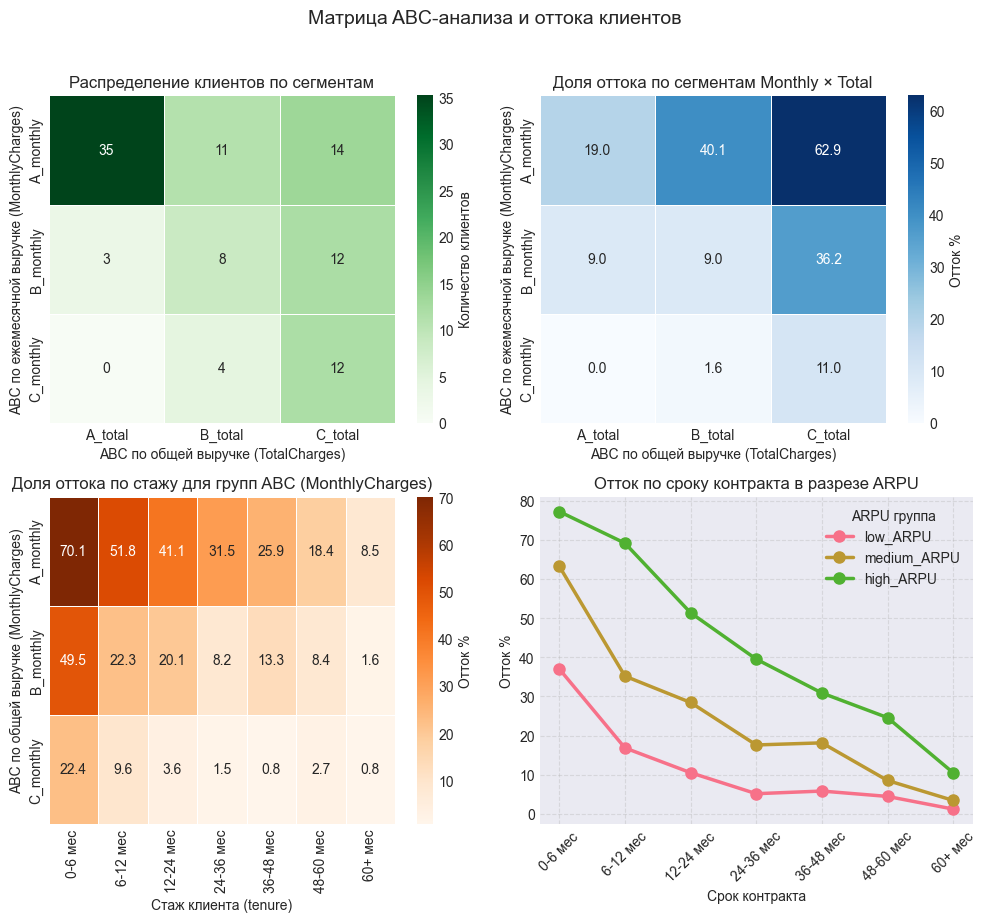

In [118]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(10,9))
fig.suptitle('Матрица ABC-анализа и оттока клиентов', fontsize=14, y=1.02)

# График 1
sns.heatmap(charges_pivot_pct, fmt='.0f', annot=True, cmap='Greens',
            ax=ax1, cbar_kws={'label': 'Количество клиентов'}, linewidths=0.5)
ax1.set_title('Распределение клиентов по сегментам')
ax1.set_xlabel('ABC по общей выручке (TotalCharges)')
ax1.set_ylabel('ABC по ежемесячной выручке (MonthlyCharges)')

# График 2
sns.heatmap(churn_pivot, fmt='.1f', annot=True, cmap='Blues',
            ax=ax2, cbar_kws={'label': 'Отток %'}, linewidths=0.5)
ax2.set_title('Доля оттока по сегментам Monthly × Total')
ax2.set_xlabel('ABC по общей выручке (TotalCharges)')
ax2.set_ylabel('ABC по ежемесячной выручке (MonthlyCharges)')

# График 3
sns.heatmap(total_tenure_pivot, fmt='.1f', annot=True, cmap='Oranges',
            ax=ax3, cbar_kws={'label': 'Отток %'}, linewidths=0.5)
ax3.set_title('Доля оттока по стажу для групп ABC (MonthlyCharges)')
ax3.set_xlabel('Стаж клиента (tenure)')
ax3.set_ylabel('ABC по общей выручке (MonthlyCharges)')

# График 4
# sns.lineplot(data=monthly_tenure_pivot, ax=ax4, x='tenure_group', hue='ARPU_group')
# Транспонируем, чтобы срок был по оси X, а ARPU — линии
plot_data = monthly_tenure_pivot.T  # теперь строки = tenure_group, колонки = ARPU_group
for arpu in plot_data.columns:
    plt.plot(plot_data.index, plot_data[arpu],
             marker='o', linewidth=2.5, markersize=8, label=arpu)
ax4.set_title('Отток по сроку контракта в разрезе ARPU')
ax4.set_xlabel('Срок контракта')
ax4.set_ylabel('Отток %')
ax4.legend(title='ARPU группа')
ax4.grid(True, alpha=0.3, color='darkgrey', linestyle='--')
ax4.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## Комментарии и выводы к графикам
По первому графику:
1. категория С-А составляет 0%, а С-В -- 4%, значит пользователи с дешевыми тарифами не могут повлиять на существенную часть выручки.  
2. Больше всего денег приносят вип клиенты АА и другие их подкатегории, то есть с высокой помесячной оплатой А.   

По втором графику:
1. Самый высокий отток в категории АС -- это клиенты с высокой помесячной оплатой, но у них низкий общий вклад, значит они уходят быстро. В категории В ежемесячной платы то же самый высокий отток среди новых клиентов. 
2. ВИП-клиенты уходят на протяжении всего срока подписки.
3. Самые стабильные -- клиенты с дешевым тарифом. 

Третий и четвертый график с разбивкой по группам ARPU в соотношении со сроком пользования подтверждают тезисы по первым двумя графикам:
1. Самая высокая доля оттока среди новых (до 6 мес) вип-клиентов - почти 80%.  
2. После 6 месяцев использования отток значительно снижается, особенно среди клиентов категорий В и С.
3. Отток среди вип клиентов снижается не так резко и продолжается на всем протяжении графика


# Комбинированная сегментация

Ранее мы разделили пользователей на группы исходя из общей потраченной на услуги суммы. Однако, ежемесячный вклад может отличаться. Так, если пользователь оплачивает дешевый тарифный план, он может быть постоянным клиентом на протяжении многих лет, но при этом приносить денег компании меньше, чем пользователь, присоединившийся не так давно, но потребляющий больше услуг и приносящий больше денег ежемесячно.

Проверим эту гипотезу.


In [119]:
# Создаем метрику, которая показывает, насколько сильно клиент "тратится" относительно среднего по своей когорте.

# Считаем средний MonthlyCharges для каждой группы по стажу
avg_by_tenure = df_charges.groupby('tenure_group')['MonthlyCharges'].transform('mean')

# Создаем индекс: платит ли клиент выше или ниже среднего для своего стажа
df_charges['spending_index'] = df_charges['MonthlyCharges'] / avg_by_tenure

# Теперь можно сегментировать по этому индексу
df_charges['spending_category'] = pd.cut(
    df_charges['spending_index'],
    bins=[0, 0.8, 1.2, float('inf')], # 1- это средний +- 20%, значит средний будет 0.8-1.2,
    #   остальное ниже среднего 0-0.8 или выше до +бесконечности
    labels=['Lower', 'Average', 'Higher']
)

# Анализируем отток
spending_analysis = df_charges.groupby('spending_category')['Churn'].agg(['mean', 'count'])
spending_analysis['mean'] = spending_analysis['mean'] * 100
print(spending_analysis.round(1))

                   mean  count
spending_category             
Lower              12.3   2227
Average            19.0   1819
Higher             41.9   2986


In [120]:
df_charges = df_charges.drop(columns='spending_index')

In [121]:
pivot = pd.pivot_table(
    df_charges,
    values='Churn',
    index='spending_category',
    columns='abc_mark',
    aggfunc='mean'
) * 100

print("Отток по spending_category и Total группе:")
print(pivot.round(1))

Отток по spending_category и Total группе:
abc_mark           A_total  B_total  C_total
spending_category                           
Lower                  6.5      4.7     17.7
Average                9.0     16.8     36.8
Higher                24.9     48.8     70.3


In [122]:
total_churned = df_charges['Churn'].sum()
print(f"Всего ушло клиентов: {total_churned}")

Всего ушло клиентов: 1869


In [123]:
# Таблица 1: spending_category × Total группа
churn__total = pd.pivot_table(
    df_charges,
    values='Churn',
    index='spending_category',
    columns='abc_mark',
    aggfunc='mean'
) * 100
print("Количество ушедших по spending_category × Total:")
print(churn__total.round(1))
churn_counts_total = pd.pivot_table(
    df_charges[df_charges['Churn'] == 1],
    values='customerID',
    index='spending_category',
    columns='abc_mark',
    aggfunc='count',
    fill_value=0
)

churn_pct_total = (churn_counts_total / total_churned * 100).round(1)

print("\nДоля в общем оттоке (%) по spending_category × Total:")
print(churn_pct_total)

Количество ушедших по spending_category × Total:
abc_mark           A_total  B_total  C_total
spending_category                           
Lower                  6.5      4.7     17.7
Average                9.0     16.8     36.8
Higher                24.9     48.8     70.3

Доля в общем оттоке (%) по spending_category × Total:
abc_mark           A_total  B_total  C_total
spending_category                           
Lower                  0.7      1.9     12.0
Average                4.3      3.3     10.8
Higher                21.3     14.8     30.9


In [124]:
pivot = pd.pivot_table(
    df_charges,
    values='Churn',
    index='spending_category',
    columns='abc_mark_monthly',
    aggfunc='mean'
) * 100

print("Отток по spending_category и Monthly группе от общего числа:")
print(pivot.round(1))

churn_counts_monthly = pd.pivot_table(
    df_charges[df_charges['Churn'] == 1],
    values='customerID',
    index='spending_category',
    columns='abc_mark_monthly',
    aggfunc='count',
    fill_value=0
)

churn_pct_monthly = (churn_counts_monthly / total_churned * 100).round(1)

print("\nДоля в общем оттоке (%) по spending_category × Monthly:")
print(churn_pct_monthly)

Отток по spending_category и Monthly группе от общего числа:
abc_mark_monthly   A_monthly  B_monthly  C_monthly
spending_category                                 
Lower                    0.0       16.6        8.5
Average                 11.5       33.9        NaN
Higher                  41.9        NaN        NaN

Доля в общем оттоке (%) по spending_category × Monthly:
abc_mark_monthly   A_monthly  B_monthly  C_monthly
spending_category                                 
Lower                    0.0        9.4        5.2
Average                  7.4       11.0        0.0
Higher                  66.9        0.0        0.0


Из этих сводных таблиц мы делаем вывод, что больше всего отписываются те, кто платит выше среднего по своей категории стажа (срока подписки) -- 66% всех отписавшихся или 42% от всех, кто платит выше среднего.   
Higher-C по TotalCharges составляет 30.9% от общего числа оттока, что является очень высоким показатем -- если они оказались в категории С, значит они успели потратить мало денег, значит совсем недолго были среди клиентов. Нужно работать над удержанием этой категории.
Те, кто платит ниже среднего, составляют ту основную массу пользователей, на которых держится бизнес (категория A-Lower), это старожилы.

Мы выяснили, что наша целевая аудитория -- это категория **Higher АВС**. Они тратят денег больше среднего, но и самые нестабильные. Теперь нам нужно составить портрет пользователя и противопоставить в этой категории тех, кто отписался тем кто остался, чтобы найти закономерности и использовать их для удержания клиентов.

## поиск закономерностей в группе Higher по spending

In [125]:
higher = df_charges[df_charges['spending_category']== 'Higher'].copy()


In [126]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn', 'abc_mark'],
      dtype='str')

In [127]:
higher = higher.merge(df[['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod']], how='left', on='customerID')
higher.head()

,customerID,tenure,MonthlyCharges,Churn,TotalCharges,abc_mark,ARPU_group,tenure_group,abc_mark_monthly,spending_category,...,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod
0,7569-NMZYQ,72,118.75,0,8672.45,A_total,high_ARPU,60+ мес,A_monthly,Higher,...,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic)
1,8984-HPEMB,71,118.65,0,8477.60,A_total,high_ARPU,60+ мес,A_monthly,Higher,...,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,Yes,Electronic check
2,5734-EJKXG,61,118.60,0,7365.70,A_total,high_ARPU,60+ мес,A_monthly,Higher,...,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,One year,Yes,Electronic check
3,5989-AXPUC,68,118.60,0,7990.05,A_total,high_ARPU,60+ мес,A_monthly,Higher,...,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,No,Mailed check
4,8199-ZLLSA,67,118.35,1,7804.15,A_total,high_ARPU,60+ мес,A_monthly,Higher,...,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,One year,Yes,Bank transfer (automatic)


In [128]:
higher.columns

Index(['customerID', 'tenure', 'MonthlyCharges', 'Churn', 'TotalCharges',
       'abc_mark', 'ARPU_group', 'tenure_group', 'abc_mark_monthly',
       'spending_category', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod'],
      dtype='str')

In [152]:
higher.OnlineSecurity.value_counts()

OnlineSecurity
No                     2099
Yes                     887
No internet service       0
Name: count, dtype: int64

In [129]:
higher_churned = higher[higher['Churn'] == 1].copy() # отписались
higher_stayed = higher[higher['Churn'] == 0].copy() # остались

Чтобы построить рекомендации по удержанию целевой группы Higher, мы составили портрет уходящего и остающегося клиента, платящего больше среднего:
- Самый надёжный клиент в группе Higher — пожилой, с семьёй (партнёр + иждивенцы), с годовым контрактом и автоплатежом.
- Самый нестабильный — молодой, одинокий, без обязательств, с помесячной оплатой и электронными чеками.

Проверим нашу гипотезу

### Составим "портрет" группы А

In [130]:
# Выделяем группу A
a_higher_churned = higher_churned[higher_churned['abc_mark_monthly']=='A_monthly'].copy()
a_higher_stayed = higher_stayed[higher_stayed['abc_mark_monthly']=='A_monthly'].copy()

In [131]:
a_higher_churned.columns

Index(['customerID', 'tenure', 'MonthlyCharges', 'Churn', 'TotalCharges',
       'abc_mark', 'ARPU_group', 'tenure_group', 'abc_mark_monthly',
       'spending_category', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod'],
      dtype='str')

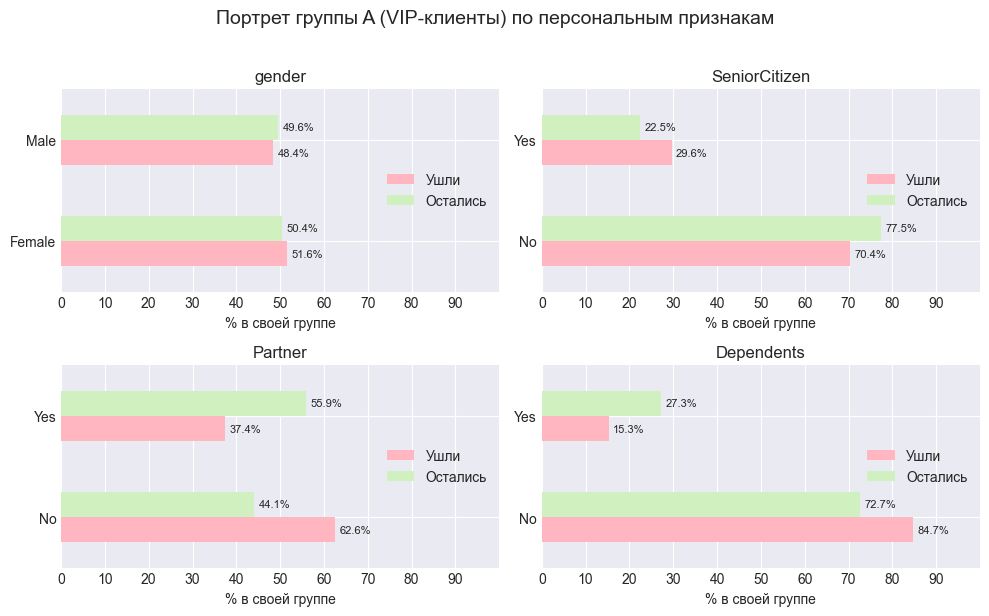

In [198]:
# Список категориальных признаков для анализа
personal_cat = ['gender', 'SeniorCitizen', 'Partner', 'Dependents']

fig, axes= plt.subplots(2,2,figsize=(10,6))
axes = axes.flatten()
for idx, cat in enumerate(personal_cat):
    dist_churned = a_higher_churned[cat].value_counts(normalize=True).mul(100).round(1)
    dist_stayed = a_higher_stayed[cat].value_counts(normalize=True).mul(100).round(1)

    comparison = pd.DataFrame({'Ушли': dist_churned,
                               'Остались': dist_stayed}).fillna(0)
    ax = comparison.plot(kind='barh', color=['#FFB6C1', '#D0F0C0'], ax=axes[idx])
    # Добавляем проценты справа от каждого столбца
    for container in ax.containers:
        ax.bar_label(container,
                    label_type='edge',  # Размещает метки на конце бара
                    padding=3,          # Отступ от бара
                    fontsize=8,          # Размер шрифта
                    fmt='%.1f%%')        # Формат числа с одним знаком после запятой
    axes[idx].set_title(cat)
    axes[idx].set_xlabel('% в своей группе')
    axes[idx].set_xlim(0, 100)
    axes[idx].set_xticks(range(0,100,10))
    axes[idx].set_ylabel(None)
    axes[idx].legend(loc='center right')

plt.suptitle('Портрет группы A (VIP-клиенты) по персональным признакам', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


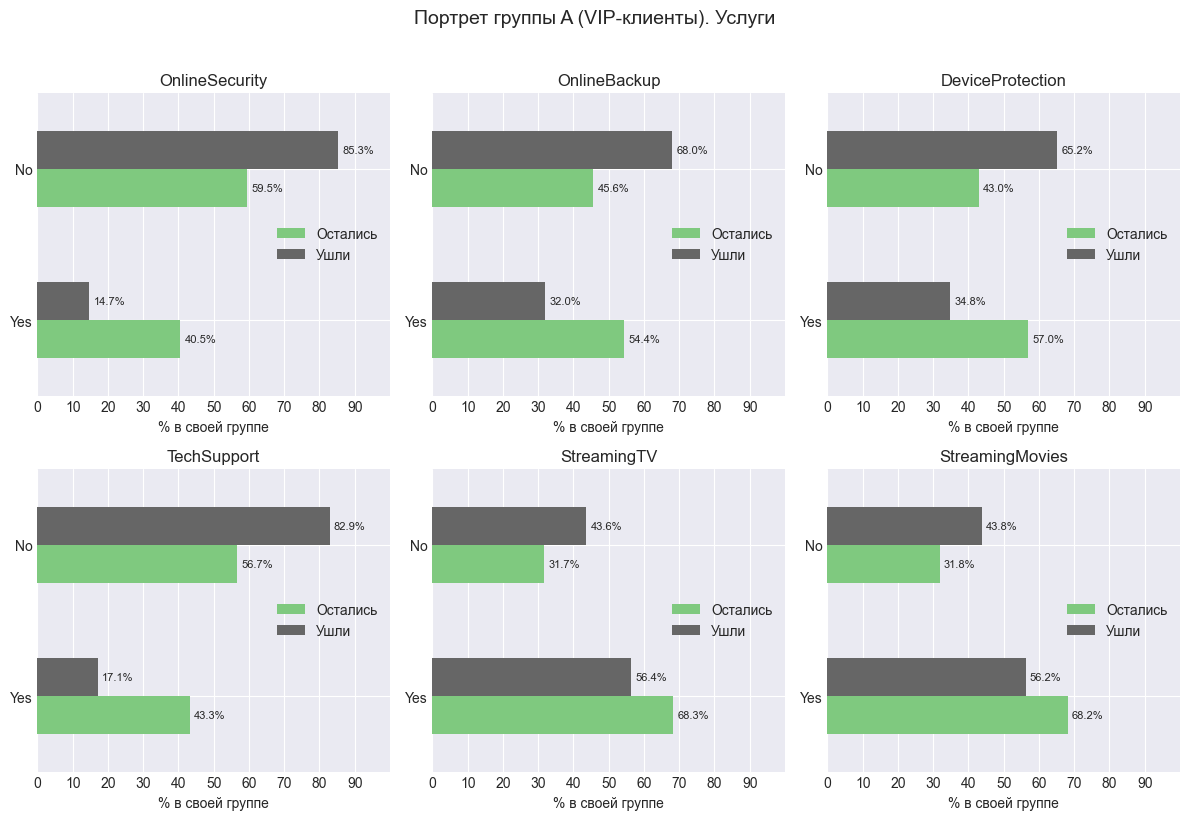

In [192]:
# список услуг
service_cat = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
            'TechSupport', 'StreamingTV', 'StreamingMovies']


fig, axes= plt.subplots(2,3,figsize=(12,8))
axes = axes.flatten()
for idx, cat in enumerate(service_cat):
    dist_churned = a_higher_churned[cat].value_counts(normalize=True).mul(100).round(1).drop(index='No internet service')
    dist_stayed = a_higher_stayed[cat].value_counts(normalize=True).mul(100).round(1).drop(index='No internet service')

    comparison = pd.DataFrame({'Остались': dist_stayed,
                               'Ушли': dist_churned,
                               }, index=['Yes', 'No']).fillna(0)
    ax = comparison.plot(kind='barh', colormap='Accent', ax=axes[idx], # legend=False
                         )
    # Добавляем проценты справа от каждого столбца
    for container in ax.containers:
        ax.bar_label(container,
                    label_type='edge',  # Размещает метки на конце бара
                    padding=3,          # Отступ от бара
                    fontsize=8,          # Размер шрифта
                    fmt='%.1f%%',
                    )        # Формат числа с одним знаком после запятой
    axes[idx].set_title(cat)
    axes[idx].set_xlabel('% в своей группе')
    axes[idx].set_ylabel(None)
    axes[idx].set_xlim(0, 100)
    axes[idx].set_xticks(range(0,100,10))
    axes[idx].legend(loc='center right')

plt.suptitle('Портрет группы A (VIP-клиенты). Услуги', fontsize=14, y=1.02)
plt.tight_layout()

plt.show()


In [ ]:
# Портрет А, стабильный: с партнёром, с иждивенцами, годовой контракт, автоплатёж
portrait_A = df[
    # (df['SeniorCitizen'] == 1) &
    ((df['Partner'] == 1) | (df['Dependents'] == 1)) &
    (df['Contract'].isin(['One year', 'Two year'])) &  # или Two year
    (df['PaymentMethod'].isin(['Bank transfer (automatic)', 'Credit card (automatic)']))
]

print(f" Портрет А (надёжный):")
print(f"   Всего клиентов: {len(portrait_A)}")
print(f"   Доля от всех клиентов: {len(portrait_A)/len(df_charges)*100:.2f}%")
print(f"   Из них в группе Higher: {(portrait_A['spending_category'] == 'Higher').sum()}")
print(f"   Отток в этой группе: {portrait_A['Churn'].mean()*100:.1f}%")
print(f"   Средний MonthlyCharges: {portrait_A['MonthlyCharges'].mean():.2f}")
print(f"   Потерянная выручка (если ушли): {portrait_A[portrait_A['Churn']==1]['MonthlyCharges'].sum()/df['MonthlyCharges'].sum()*100:.2f}% от общей выручки в месяц")

 Портрет А (надёжный):
   Всего клиентов: 1371
   Доля от всех клиентов: 19.47%
   Из них в группе Higher: 440
   Отток в этой группе: 5.1%
   Средний MonthlyCharges: 67.06
   Потерянная выручка (если ушли): 1.32% от общей выручки в месяц


In [ ]:
# Портрет А2: пенсионеры (с любыми условиями)
portrait_A2 = df[
    (df['SeniorCitizen'] == 1)
]

print(f"\n👴 Портрет А2 (пенсионеры):")
print(f"   Всего клиентов: {len(portrait_A2)}")
print(f"   Доля от всех клиентов: {len(portrait_A2)/len(df)*100:.2f}%")
print(f"   Из них в группе Higher: {(portrait_A2['spending_category'] == 'Higher').sum()}")
print(f"   Отток в этой группе: {portrait_A2['Churn'].mean()*100:.1f}%")
print(f"   Средний MonthlyCharges: {portrait_A2['MonthlyCharges'].mean():.2f}")
print(f"   Потерянная выручка: {portrait_A2[portrait_A2['Churn']==1]['MonthlyCharges'].sum()/df['MonthlyCharges'].sum()*100:.2f}%")


👴 Портрет А2 (пенсионеры):
   Всего клиентов: 1142
   Доля от всех клиентов: 16.21%
   Из них в группе Higher: 761
   Отток в этой группе: 41.7%
   Средний MonthlyCharges: 79.82
   Потерянная выручка: 8.42%


In [ ]:
# Портрет С: молодой, без партнёра, без иждивенцев, помесячный контракт, электронные чеки
portrait_C = df[
    (df['SeniorCitizen'] == 0) &
    (df['Partner'] == 0) &
    (df['Dependents'] == 0) &
    (df['Contract'] == 'Month-to-month') &
    (df['PaymentMethod'] == 'Electronic check')
]

print(f"\n Портрет С (нестабильный):")
print(f"   Всего клиентов: {len(portrait_C)}")
print(f"   Доля от всех клиентов: {len(portrait_C)/len(df_charges)*100:.2f}%")
print(f"   Из них в группе Higher: {(portrait_C['spending_category'] == 'Higher').sum()}")
print(f"   Из них в группе C по Total: {(portrait_C['abc_mark'] == 'C').sum()}")
print(f"   Отток в этой группе: {portrait_C['Churn'].mean()*100:.1f}%")
print(f"   Средний MonthlyCharges: {portrait_C['MonthlyCharges'].mean():.2f}")
print(f"   Потерянная выручка (если ушли): {portrait_C[portrait_C['Churn']==1]['MonthlyCharges'].sum()/df['MonthlyCharges'].sum()*100:.2f}% от общей выручки в месяц")


 Портрет С (нестабильный):
   Всего клиентов: 805
   Доля от всех клиентов: 11.43%
   Из них в группе Higher: 516
   Из них в группе C по Total: 517
   Отток в этой группе: 54.4%
   Средний MonthlyCharges: 71.77
   Потерянная выручка (если ушли): 7.24% от общей выручки в месяц


# Выводы исследования

1. Оператор привлекает дорогих клиентов, но плохо удерживает их. Нужно разработать стратегию по удержанию вип-клиентов и средних. 

2. Постоянные клиенты "сидят" на дешевых тарифах и приносят мало денег компании.

3. Группа А (TotalCharges), приносящая 80% прибыли компании и составляющая ~ 40% ее аудитории -- наиболее устойчива к оттоку, доля оттока менее 20%.
Из этого можно сделать вывод, что группа А по TotalCharges состоит большей частью из неновых вип-пользоваталей.

4. Наибольший процент оттока среди клиентов с помесячной оплатой 55.78 и без автооплаты (электронные чеки - 53.06%, почтовые чеки - 40.94%).

5. Подключенные слуги 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport' снижают процент оттока, особенно это заметно на пожилых клиентах.

6. Наличие партнера и/или иждивенца существенно снижает вероятность отписки.


Чтобы построить рекомендации по удержанию целевой группы Higher, я составила портрет уходящего и остающегося клиента, платящего больше среднего:
- Самый надёжный клиент в группе Higher — с семьёй (партнёр + иждивенцы), с годовым контрактом и автоплатежом.
- Самый нестабильный — молодой, одинокий, без обязательств, с помесячной оплатой и электронными чеками.